<a href="https://colab.research.google.com/github/mohaipro/Sentiments_Text/blob/main/medical_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# for smote algorithm (oversampling / upsampling)
pip install imblearn

In [72]:
# Import the NumPy library for numerical operations
import numpy as np

# Import the pyplot module from matplotlib for plotting and visualization
import matplotlib.pyplot as plt

# Import the pandas library for data manipulation and analysis
import pandas as pd

In [73]:
# Read the CSV file "hospital.csv" into a pandas DataFrame
df = pd.read_csv("hospital.csv")

# Display the first five rows of the DataFrame to inspect the data
df.head()

,Feedback,Sentiment Label,Ratings,Unnamed: 3
0,Good and clean hospital. There is great team o...,1,5,NaN
1,Had a really bad experience during discharge. ...,1,5,NaN
2,I have visited to take my second dose and Proc...,1,4,NaN
3,That person was slightly clueless and offered...,1,3,NaN
4,There is great team of doctors and good OT fac...,0,1,NaN


In [74]:
# drop the last column for processing
df = df.drop(columns=['Ratings','Unnamed: 3'])

# printing the df in the console
df.head()

,Feedback,Sentiment Label
0,Good and clean hospital. There is great team o...,1
1,Had a really bad experience during discharge. ...,1
2,I have visited to take my second dose and Proc...,1
3,That person was slightly clueless and offered...,1
4,There is great team of doctors and good OT fac...,0


In [75]:
# Calculate and display the number of samples (rows) in the dataset
num_samples = len(df)

# Calculate and display the number of features (columns), including the target output
num_features = len(df.columns)

# Output the results (statistics for the dataset)
print("Number of samples (records) in the dataset:", num_samples)
print("Number of features + target included:", num_features)
print("Shape of the dataset:", df.shape)
print("Columns names for the dataset:",df.columns.tolist())

Number of samples (records) in the dataset: 996
Number of features + target included: 2
Shape of the dataset: (996, 2)
Columns names for the dataset: ['Feedback', 'Sentiment Label']


In [76]:
# Calculate the number of unique sentiment classes in the 'airline_sentiment' column
num_classes = len(df[df.columns.tolist()[1]].value_counts())

# Display the number of unique sentiment classes
print("number of classes in the dataset:",num_classes)

# Display the count of samples for each sentiment class
print(df[df.columns.tolist()[1]].value_counts())

number of classes in the dataset: 2
Sentiment Label
1    728
0    268
Name: count, dtype: int64


In [77]:
# print sample complete text from the dataset
idx = 0
print(df.Feedback[idx])

Good and clean hospital. There is great team of doctors and good OT facility. The medical facilities are all great with good in-patient post operative care by doctors, nurses. The housekeeping staff is also good but they can respond to calls from the room a little faster. 


In [78]:
# Display summary statistics for numerical columns
df.describe()

,Sentiment Label
count,996.000000
mean,0.730924
std,0.443703
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [79]:
# See the information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 996 entries, 0 to 995
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Feedback         996 non-null    object
 1   Sentiment Label  996 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 15.7+ KB


In [80]:
# Display the number of missing (null) values in each column of the DataFrame
print(df.isnull().sum())

Feedback           0
Sentiment Label    0
dtype: int64


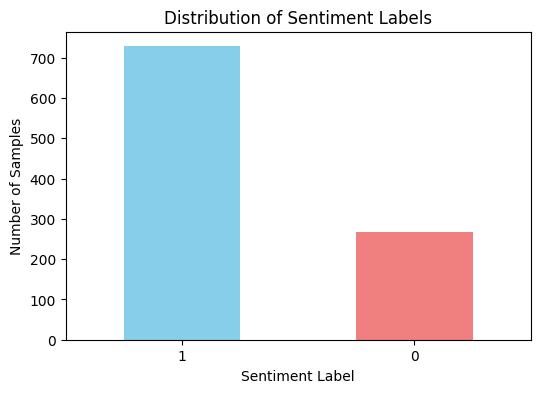

In [81]:
# Get the value counts of the 'Sentiment Label' column
sentiment_counts = df['Sentiment Label'].value_counts()

# Create a bar plot
plt.figure(figsize=(6, 4))
sentiment_counts.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.show()

In [82]:
# Select the 'text' column as the feature set (X) containing the sample texts
X = df["Feedback"]

# Select the 'airline_sentiment' column as the target variable (y) containing sentiment labels
y = df["Sentiment Label"]

In [83]:
# Display an example tweet and its corresponding sentiment label
# X contains the tweet texts, y contains the sentiment labels

idx = 24

# Show an example of the data we use
print("Example of the data we use:")
print(X[idx])
print()

# Show the corresponding sentiment
print("Corresponding Sentiment:")
print(y[idx])

Example of the data we use:
a very nice experience during our stay and Treatment in the Fortis Hospital from 27-7-2023 to 3-8-2023. We felt like staying in our own home. Dr.Rajkumar Deshpande and his team Done the C1& C2 Surgical Spine Replacement under O arm Machine successfully .Doctors and other supporting staff for their wonderful services.

Corresponding Sentiment:
1


In [84]:
# Import necessary libraries for text preprocessing and feature extraction
import string  # For handling punctuation
import re      # For regular expressions (used in emoji removal)
import nltk    # Natural Language Toolkit for tokenization
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer, TfidfVectorizer
from nltk.tokenize import word_tokenize

# Download required NLTK data files for tokenization
nltk.download('punkt')
nltk.download('punkt_tab')

def remove_emojis(text):
    """
    Remove emojis from the input text using a regular expression pattern
    that matches a wide range of Unicode emoji characters.
    """
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002700-\U000027BF"  # Dingbats
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

def preprocess_text(text):
    """
    Preprocess a single tweet by:
    1. Removing emojis.
    2. Lowercasing all text.
    3. Tokenizing the text into words.
    4. Removing punctuation tokens.
    5. Removing English stopwords.
    6. Removing the first token (assumed to be '@VirginAmerica').
    7. Joining the tokens back into a single string.
    """
    # Remove emojis from the text
    text = remove_emojis(text)
    # Convert text to lowercase
    text = text.lower()
    # Tokenize text into words
    words = word_tokenize(text)
    # Remove punctuation tokens
    words = [word for word in words if word not in string.punctuation]
    # Remove English stopwords
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    # Join the tokens back into a single string
    return ' '.join(words)

# Apply the preprocessing function to each tweet in the feature set X
X_processed = X.apply(preprocess_text)

# # Display the first few preprocessed tweets
X_processed.head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,Feedback
0,good clean hospital great team doctors good ot...
1,really bad experience discharge need sensitive...
2,visited second dose process really smooth hosp...
3,person slightly clueless offered package got h...
4,great team doctors good ot facility


In [85]:
# showing the sentence before and after preprosessing
idx = 0
print("Sentence before processing:")
print(X[idx],"\n")
# Print a separator line for clarity in output
print("#"*200,"\n")
print("Sentence after processing:")
print(preprocess_text(X[idx]))

Sentence before processing:
Good and clean hospital. There is great team of doctors and good OT facility. The medical facilities are all great with good in-patient post operative care by doctors, nurses. The housekeeping staff is also good but they can respond to calls from the room a little faster.  

######################################################################################################################################################################################################## 

Sentence after processing:
good clean hospital great team doctors good ot facility medical facilities great good in-patient post operative care doctors nurses housekeeping staff good respond calls room little faster


In [87]:
# defining mappings for further processing!
mapping_dict_n2l = {0:"negative", 1:"positive"}
mapping_dict_l2n = {"negative":0, "positive":1}

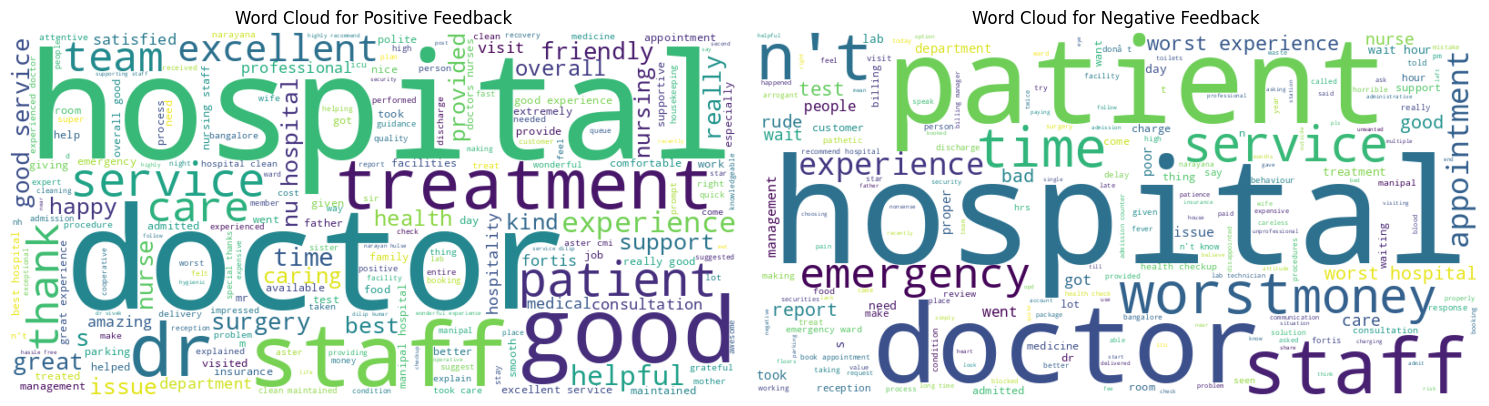

In [248]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Install wordcloud if not already installed
try:
    from wordcloud import WordCloud
except ImportError:
    !pip install wordcloud
    from wordcloud import WordCloud

# Separate positive and negative feedback
positive_feedback = X_processed[y == 1]
negative_feedback = X_processed[y == 0]

# Join all words in positive feedback into a single string
all_positive_words = ' '.join([text for text in positive_feedback])

# Join all words in negative feedback into a single string
all_negative_words = ' '.join([text for text in negative_feedback])

# Generate word cloud for positive feedback
wordcloud_positive = WordCloud(width=800, height=400, background_color='white').generate(all_positive_words)

# Generate word cloud for negative feedback
wordcloud_negative = WordCloud(width=800, height=400, background_color='white').generate(all_negative_words)

# Plotting the word clouds
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.title('Word Cloud for Positive Feedback')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.title('Word Cloud for Negative Feedback')
plt.axis('off')

plt.tight_layout()
plt.show()

In [219]:
# Initialize TfidfVectorizer. You can adjust parameters like max_features, min_df, max_df as needed.
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,2),max_features=2000)

# Fit and transform the preprocessed text data (X_processed)
X_tfidf = tfidf_vectorizer.fit_transform(X_processed)

print("Shape of TF-IDF feature matrix:", X_tfidf.shape)
print("Example of TF-IDF features (for the first document, non-zero values):")
print(X_tfidf[0])

Shape of TF-IDF feature matrix: (996, 2000)
Example of TF-IDF features (for the first document, non-zero values):
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 48 stored elements and shape (1, 2000)>
  Coords	Values
  (0, 620)	0.23359190441648803
  (0, 247)	0.10973134194503265
  (0, 699)	0.0516074426428059
  (0, 644)	0.194071383012564
  (0, 1865)	0.08870991093189413
  (0, 453)	0.14651761185628093
  (0, 1223)	0.1500385177842225
  (0, 560)	0.13106118588741858
  (0, 1032)	0.11601302340308593
  (0, 557)	0.11929044541162724
  (0, 809)	0.1500385177842225
  (0, 1258)	0.08074136260869563
  (0, 1331)	0.13106118588741858
  (0, 1205)	0.13516139575515596
  (0, 181)	0.07864627289159112
  (0, 1173)	0.09799833276952935
  (0, 767)	0.13516139575515596
  (0, 1722)	0.06601937377511534
  (0, 1506)	0.1500385177842225
  (0, 162)	0.1500385177842225
  (0, 1538)	0.12447685933705675
  (0, 947)	0.14297758973438585
  (0, 567)	0.14008669864349085
  (0, 623)	0.15451345563309418
  (0, 249)	0.15451345

In [220]:
# creating df with features and labels
X_new = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

print("X_new dataframe shape = ", X_new.shape)

X_new dataframe shape =  (996, 2000)


In [221]:
print("Shape of X_new:",X_new.shape)
print("Shape of y:",y.shape)

Shape of X_new: (996, 2000)
Shape of y: (996,)


In [222]:
# Import SMOTE for oversampling
from imblearn.over_sampling import SMOTE
from collections import Counter

# Apply SMOTE to the dataset with processed features
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_new, y)

print(f"Original dataset shape: {Counter(y)}")
print(f"Resampled dataset shape: {Counter(y_resampled)}")

Original dataset shape: Counter({1: 728, 0: 268})
Resampled dataset shape: Counter({1: 728, 0: 728})


In [223]:
print("X_new dataframe shape = ", X_resampled.shape)
print("y_new dataframe shape = ", y_resampled.shape)

X_new dataframe shape =  (1456, 2000)
y_new dataframe shape =  (1456,)


As you can see from the `Resampled dataset shape`, the 'Sentiment Label' classes are now balanced after applying SMOTE to the TF-IDF vectorized features.

In [224]:
# Import train_test_split for splitting the dataset
from sklearn.model_selection import train_test_split

# Perform train-test split on the resampled data
# X_resampled contains the features (TF-IDF vectors)
# y_resampled contains the target labels (Sentiment Label)
# test_size=0.2 means 20% of the data will be used for testing
# random_state=42 ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Print the shapes of the resulting datasets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1164, 2000)
Shape of X_test: (292, 2000)
Shape of y_train: (1164,)
Shape of y_test: (292,)


In [225]:
# Import necessary libraries for Logistic Regression and evaluation metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, log_loss

# 1. Initialize the Logistic Regression model
# Set solver and max_iter for better convergence with TF-IDF features
logistic_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=200)

# 2. Fit the model to the training data
print("Training Logistic Regression model...")
logistic_model.fit(X_train, y_train)
print("Model training complete.")

# 3. Make predictions on the test set
y_pred = logistic_model.predict(X_test)

# 4. Calculate probabilities for logistic loss (if needed)
y_pred_proba = logistic_model.predict_proba(X_test)

# 5. Evaluate the model
print("\n--- Model Evaluation ---")

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Classification Report (precision, recall, f1-score for each class)
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

# Logistic Loss (or Cross-Entropy Loss)
# Make sure y_pred_proba has probabilities for both classes for log_loss
# If it's a binary classification, predict_proba returns two columns [prob_class_0, prob_class_1]
# We need the probability of the positive class if y_test is binary (0/1)
if y_pred_proba.shape[1] == 2:
    loss = log_loss(y_test, y_pred_proba[:, 1])
else:
    loss = log_loss(y_test, y_pred_proba) # For multiclass if y_test is one-hot or similar
print(f"Logistic Loss: {loss:.4f}")


Training Logistic Regression model...
Model training complete.

--- Model Evaluation ---
Accuracy Score: 0.9178

Confusion Matrix:
[[135   9]
 [ 15 133]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       144
           1       0.94      0.90      0.92       148

    accuracy                           0.92       292
   macro avg       0.92      0.92      0.92       292
weighted avg       0.92      0.92      0.92       292

Logistic Loss: 0.3384


In [226]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, log_loss

# 1. Initialize the K-Nearest Neighbors model
# You can experiment with different values for n_neighbors
knn_model = KNeighborsClassifier(n_neighbors=3)

# 2. Fit the model to the training data
print("Training K-Nearest Neighbors model...")
knn_model.fit(X_train, y_train)
print("Model training complete.")

# 3. Make predictions on the test set
y_pred_knn = knn_model.predict(X_test)

# 4. Calculate probabilities for logistic loss (if needed)
y_pred_proba_knn = knn_model.predict_proba(X_test)

# 5. Evaluate the model
print("\n--- KNN Model Evaluation ---")

# Accuracy Score
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy Score (KNN): {accuracy_knn:.4f}")

# Confusion Matrix
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
print("\nConfusion Matrix (KNN):")
print(conf_matrix_knn)

# Classification Report (precision, recall, f1-score for each class)
class_report_knn = classification_report(y_test, y_pred_knn)
print("\nClassification Report (KNN):")
print(class_report_knn)

# Logistic Loss (or Cross-Entropy Loss)
# For binary classification, log_loss expects probabilities of the positive class
if y_pred_proba_knn.shape[1] == 2:
    loss_knn = log_loss(y_test, y_pred_proba_knn[:, 1])
else:
    loss_knn = log_loss(y_test, y_pred_proba_knn) # Fallback for multiclass
print(f"Logistic Loss (KNN): {loss_knn:.4f}")

Training K-Nearest Neighbors model...
Model training complete.

--- KNN Model Evaluation ---
Accuracy Score (KNN): 0.7021

Confusion Matrix (KNN):
[[144   0]
 [ 87  61]]

Classification Report (KNN):
              precision    recall  f1-score   support

           0       0.62      1.00      0.77       144
           1       1.00      0.41      0.58       148

    accuracy                           0.70       292
   macro avg       0.81      0.71      0.68       292
weighted avg       0.81      0.70      0.67       292

Logistic Loss (KNN): 6.1356


In [227]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, log_loss

# 1. Initialize the Multinomial Naive Bayes model
naive_bayes_model = MultinomialNB()

# 2. Fit the model to the training data
print("Training Naive Bayes model...")
naive_bayes_model.fit(X_train, y_train)
print("Model training complete.")

# 3. Make predictions on the test set
y_pred_nb = naive_bayes_model.predict(X_test)

# 4. Calculate probabilities for logistic loss
y_pred_proba_nb = naive_bayes_model.predict_proba(X_test)

# 5. Evaluate the model
print("\n--- Naive Bayes Model Evaluation ---")

# Accuracy Score
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Accuracy Score (Naive Bayes): {accuracy_nb:.4f}")

# Confusion Matrix
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)
print("\nConfusion Matrix (Naive Bayes):")
print(conf_matrix_nb)

# Classification Report (precision, recall, f1-score for each class)
class_report_nb = classification_report(y_test, y_pred_nb)
print("\nClassification Report (Naive Bayes):")
print(class_report_nb)

# Logistic Loss (or Cross-Entropy Loss)
# For binary classification, log_loss expects probabilities of the positive class
if y_pred_proba_nb.shape[1] == 2:
    loss_nb = log_loss(y_test, y_pred_proba_nb[:, 1])
else:
    loss_nb = log_loss(y_test, y_pred_proba_nb) # Fallback for multiclass
print(f"Logistic Loss (Naive Bayes): {loss_nb:.4f}")

Training Naive Bayes model...
Model training complete.

--- Naive Bayes Model Evaluation ---
Accuracy Score (Naive Bayes): 0.9110

Confusion Matrix (Naive Bayes):
[[142   2]
 [ 24 124]]

Classification Report (Naive Bayes):
              precision    recall  f1-score   support

           0       0.86      0.99      0.92       144
           1       0.98      0.84      0.91       148

    accuracy                           0.91       292
   macro avg       0.92      0.91      0.91       292
weighted avg       0.92      0.91      0.91       292

Logistic Loss (Naive Bayes): 0.2830


In [228]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, log_loss

# 1. Initialize the Support Vector Machine model
# Using a linear kernel often works well for text data (TF-IDF features)
# probability=True enables predict_proba, which is needed for log_loss
# Consider using LinearSVC for larger datasets and CalibratedClassifierCV for calibrated probabilities if performance is an issue.
svm_model = SVC(kernel='linear', random_state=42, probability=True)

# 2. Fit the model to the training data
print("Training SVM model...")
svm_model.fit(X_train, y_train)
print("Model training complete.")

# 3. Make predictions on the test set
y_pred_svm = svm_model.predict(X_test)

# 4. Calculate probabilities for logistic loss
y_pred_proba_svm = svm_model.predict_proba(X_test)

# 5. Evaluate the model
print("\n--- SVM Model Evaluation ---")

# Accuracy Score
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy Score (SVM): {accuracy_svm:.4f}")

# Confusion Matrix
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
print("\nConfusion Matrix (SVM):")
print(conf_matrix_svm)

# Classification Report (precision, recall, f1-score for each class)
class_report_svm = classification_report(y_test, y_pred_svm)
print("\nClassification Report (SVM):")
print(class_report_svm)

# Logistic Loss (or Cross-Entropy Loss)
# For binary classification, log_loss expects probabilities of the positive class
if y_pred_proba_svm.shape[1] == 2:
    loss_svm = log_loss(y_test, y_pred_proba_svm[:, 1])
else:
    loss_svm = log_loss(y_test, y_pred_proba_svm) # Fallback for multiclass
print(f"Logistic Loss (SVM): {loss_svm:.4f}")

Training SVM model...
Model training complete.

--- SVM Model Evaluation ---
Accuracy Score (SVM): 0.9178

Confusion Matrix (SVM):
[[141   3]
 [ 21 127]]

Classification Report (SVM):
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       144
           1       0.98      0.86      0.91       148

    accuracy                           0.92       292
   macro avg       0.92      0.92      0.92       292
weighted avg       0.92      0.92      0.92       292

Logistic Loss (SVM): 0.2016


In [229]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, log_loss

# 1. Initialize the Random Forest model
# You can adjust parameters like n_estimators (number of trees) or max_depth
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Fit the model to the training data
print("Training Random Forest model...")
random_forest_model.fit(X_train, y_train)
print("Model training complete.")

# 3. Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test)

# 4. Calculate probabilities for logistic loss
y_pred_proba_rf = random_forest_model.predict_proba(X_test)

# 5. Evaluate the model
print("\n--- Random Forest Model Evaluation ---")

# Accuracy Score
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy Score (Random Forest): {accuracy_rf:.4f}")

# Confusion Matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix (Random Forest):")
print(conf_matrix_rf)

# Classification Report (precision, recall, f1-score for each class)
class_report_rf = classification_report(y_test, y_pred_rf)
print("\nClassification Report (Random Forest):")
print(class_report_rf)

# Logistic Loss (or Cross-Entropy Loss)
# For binary classification, log_loss expects probabilities of the positive class
if y_pred_proba_rf.shape[1] == 2:
    loss_rf = log_loss(y_test, y_pred_proba_rf[:, 1])
else:
    loss_rf = log_loss(y_test, y_pred_proba_rf) # Fallback for multiclass
print(f"Logistic Loss (Random Forest): {loss_rf:.4f}")

Training Random Forest model...
Model training complete.

--- Random Forest Model Evaluation ---
Accuracy Score (Random Forest): 0.9075

Confusion Matrix (Random Forest):
[[129  15]
 [ 12 136]]

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.91      0.90      0.91       144
           1       0.90      0.92      0.91       148

    accuracy                           0.91       292
   macro avg       0.91      0.91      0.91       292
weighted avg       0.91      0.91      0.91       292

Logistic Loss (Random Forest): 0.2510


In [230]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, log_loss

# 1. Initialize the Decision Tree model
# You can adjust parameters like max_depth, min_samples_leaf, etc.
decision_tree_model = DecisionTreeClassifier(random_state=42)

# 2. Fit the model to the training data
print("Training Decision Tree model...")
decision_tree_model.fit(X_train, y_train)
print("Model training complete.")

# 3. Make predictions on the test set
y_pred_dt = decision_tree_model.predict(X_test)

# 4. Calculate probabilities for logistic loss
y_pred_proba_dt = decision_tree_model.predict_proba(X_test)

# 5. Evaluate the model
print("\n--- Decision Tree Model Evaluation ---")

# Accuracy Score
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy Score (Decision Tree): {accuracy_dt:.4f}")

# Confusion Matrix
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
print("\nConfusion Matrix (Decision Tree):")
print(conf_matrix_dt)

# Classification Report (precision, recall, f1-score for each class)
class_report_dt = classification_report(y_test, y_pred_dt)
print("\nClassification Report (Decision Tree):")
print(class_report_dt)

# Logistic Loss (or Cross-Entropy Loss)
# For binary classification, log_loss expects probabilities of the positive class
if y_pred_proba_dt.shape[1] == 2:
    loss_dt = log_loss(y_test, y_pred_proba_dt[:, 1])
else:
    loss_dt = log_loss(y_test, y_pred_proba_dt) # Fallback for multiclass
print(f"Logistic Loss (Decision Tree): {loss_dt:.4f}")

Training Decision Tree model...
Model training complete.

--- Decision Tree Model Evaluation ---
Accuracy Score (Decision Tree): 0.8356

Confusion Matrix (Decision Tree):
[[117  27]
 [ 21 127]]

Classification Report (Decision Tree):
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       144
           1       0.82      0.86      0.84       148

    accuracy                           0.84       292
   macro avg       0.84      0.84      0.84       292
weighted avg       0.84      0.84      0.84       292

Logistic Loss (Decision Tree): 5.9274


In [231]:
# Install xgboost if not already installed
try:
    import xgboost
except ImportError:
    !pip install xgboost
    import xgboost

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, log_loss

# 1. Initialize the XGBoost model
# You can adjust parameters like n_estimators, learning_rate, max_depth, etc.
# Use 'objective="binary:logistic"' for binary classification and 'eval_metric="logloss"' for consistent loss calculation.
xgboost_model = XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)

# 2. Fit the model to the training data
print("Training XGBoost model...")
xgboost_model.fit(X_train, y_train)
print("Model training complete.")

# 3. Make predictions on the test set
y_pred_xgb = xgboost_model.predict(X_test)

# 4. Calculate probabilities for logistic loss
y_pred_proba_xgb = xgboost_model.predict_proba(X_test)

# 5. Evaluate the model
print("\n--- XGBoost Model Evaluation ---")

# Accuracy Score
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Accuracy Score (XGBoost): {accuracy_xgb:.4f}")

# Confusion Matrix
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
print("\nConfusion Matrix (XGBoost):")
print(conf_matrix_xgb)

# Classification Report (precision, recall, f1-score for each class)
class_report_xgb = classification_report(y_test, y_pred_xgb)
print("\nClassification Report (XGBoost):")
print(class_report_xgb)

# Logistic Loss (or Cross-Entropy Loss)
# For binary classification, log_loss expects probabilities of the positive class
if y_pred_proba_xgb.shape[1] == 2:
    loss_xgb = log_loss(y_test, y_pred_proba_xgb[:, 1])
else:
    loss_xgb = log_loss(y_test, y_pred_proba_xgb) # Fallback for multiclass
print(f"Logistic Loss (XGBoost): {loss_xgb:.4f}")

Training XGBoost model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:36:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model training complete.

--- XGBoost Model Evaluation ---
Accuracy Score (XGBoost): 0.8733

Confusion Matrix (XGBoost):
[[122  22]
 [ 15 133]]

Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       144
           1       0.86      0.90      0.88       148

    accuracy                           0.87       292
   macro avg       0.87      0.87      0.87       292
weighted avg       0.87      0.87      0.87       292

Logistic Loss (XGBoost): 0.2524


In [232]:
from sklearn.metrics import accuracy_score, log_loss

# --- Calculate Training Metrics for Logistic Regression ---
y_train_pred_lr = logistic_model.predict(X_train)
y_train_pred_proba_lr = logistic_model.predict_proba(X_train)
training_accuracy_lr = accuracy_score(y_train, y_train_pred_lr)
training_loss_lr = log_loss(y_train, y_train_pred_proba_lr[:, 1])

# --- Calculate Training Metrics for K-Nearest Neighbors ---
y_train_pred_knn = knn_model.predict(X_train)
y_train_pred_proba_knn = knn_model.predict_proba(X_train)
training_accuracy_knn = accuracy_score(y_train, y_train_pred_knn)
training_loss_knn = log_loss(y_train, y_train_pred_proba_knn[:, 1])

# --- Calculate Training Metrics for Naive Bayes ---
y_train_pred_nb = naive_bayes_model.predict(X_train)
y_train_pred_proba_nb = naive_bayes_model.predict_proba(X_train)
training_accuracy_nb = accuracy_score(y_train, y_train_pred_nb)
training_loss_nb = log_loss(y_train, y_train_pred_proba_nb[:, 1])

# --- Calculate Training Metrics for Support Vector Machine ---
y_train_pred_svm = svm_model.predict(X_train)
y_train_pred_proba_svm = svm_model.predict_proba(X_train)
training_accuracy_svm = accuracy_score(y_train, y_train_pred_svm)
training_loss_svm = log_loss(y_train, y_train_pred_proba_svm[:, 1])

# --- Calculate Training Metrics for Random Forest ---
y_train_pred_rf = random_forest_model.predict(X_train)
y_train_pred_proba_rf = random_forest_model.predict_proba(X_train)
training_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
training_loss_rf = log_loss(y_train, y_train_pred_proba_rf[:, 1])

# --- Calculate Training Metrics for Decision Tree ---
y_train_pred_dt = decision_tree_model.predict(X_train)
y_train_pred_proba_dt = decision_tree_model.predict_proba(X_train)
training_accuracy_dt = accuracy_score(y_train, y_train_pred_dt)
training_loss_dt = log_loss(y_train, y_train_pred_proba_dt[:, 1])

# --- Calculate Training Metrics for XGBoost ---
y_train_pred_xgb = xgboost_model.predict(X_train)
y_train_pred_proba_xgb = xgboost_model.predict_proba(X_train)
training_accuracy_xgb = accuracy_score(y_train, y_train_pred_xgb)
training_loss_xgb = log_loss(y_train, y_train_pred_proba_xgb[:, 1])

print("Training metrics calculated for all models.")

Training metrics calculated for all models.


In [233]:
import pandas as pd

# Create a dictionary to store model names, accuracies, and losses
results = {
    'Model': [
        'Logistic Regression',
        'K-Nearest Neighbors',
        'Naive Bayes',
        'Support Vector Machine',
        'Random Forest',
        'Decision Tree',
        'XGBoost'
    ],
    'Training Accuracy': [
        training_accuracy_lr,
        training_accuracy_knn,
        training_accuracy_nb,
        training_accuracy_svm,
        training_accuracy_rf,
        training_accuracy_dt,
        training_accuracy_xgb
    ],
    'Testing Accuracy': [
        accuracy,
        accuracy_knn,
        accuracy_nb,
        accuracy_svm,
        accuracy_rf,
        accuracy_dt,
        accuracy_xgb
    ],
    'Training Logistic Loss': [
        training_loss_lr,
        training_loss_knn,
        training_loss_nb,
        training_loss_svm,
        training_loss_rf,
        training_loss_dt,
        training_loss_xgb
    ],
    'Testing Logistic Loss': [
        loss,
        loss_knn,
        loss_nb,
        loss_svm,
        loss_rf,
        loss_dt,
        loss_xgb
    ]
}

# Create a Pandas DataFrame from the results dictionary
results_df = pd.DataFrame(results)

# Sort the DataFrame by Testing Accuracy in descending order for better comparison
results_df = results_df.sort_values(by='Testing Accuracy', ascending=False).reset_index(drop=True)

# Display the table
print("\n\t\t\t\t\t--- Model Performance Summary ---")
print(results_df.to_markdown(index=False))


					--- Model Performance Summary ---
| Model                  |   Training Accuracy |   Testing Accuracy |   Training Logistic Loss |   Testing Logistic Loss |
|:-----------------------|--------------------:|-------------------:|-------------------------:|------------------------:|
| Logistic Regression    |            0.963918 |           0.917808 |               0.299983   |                0.338353 |
| Support Vector Machine |            0.979381 |           0.917808 |               0.0790221  |                0.201555 |
| Naive Bayes            |            0.949313 |           0.910959 |               0.220528   |                0.282958 |
| Random Forest          |            0.998282 |           0.907534 |               0.0736187  |                0.250999 |
| XGBoost                |            0.982818 |           0.873288 |               0.0955647  |                0.25244  |
| Decision Tree          |            0.998282 |           0.835616 |               0.00238195 |   

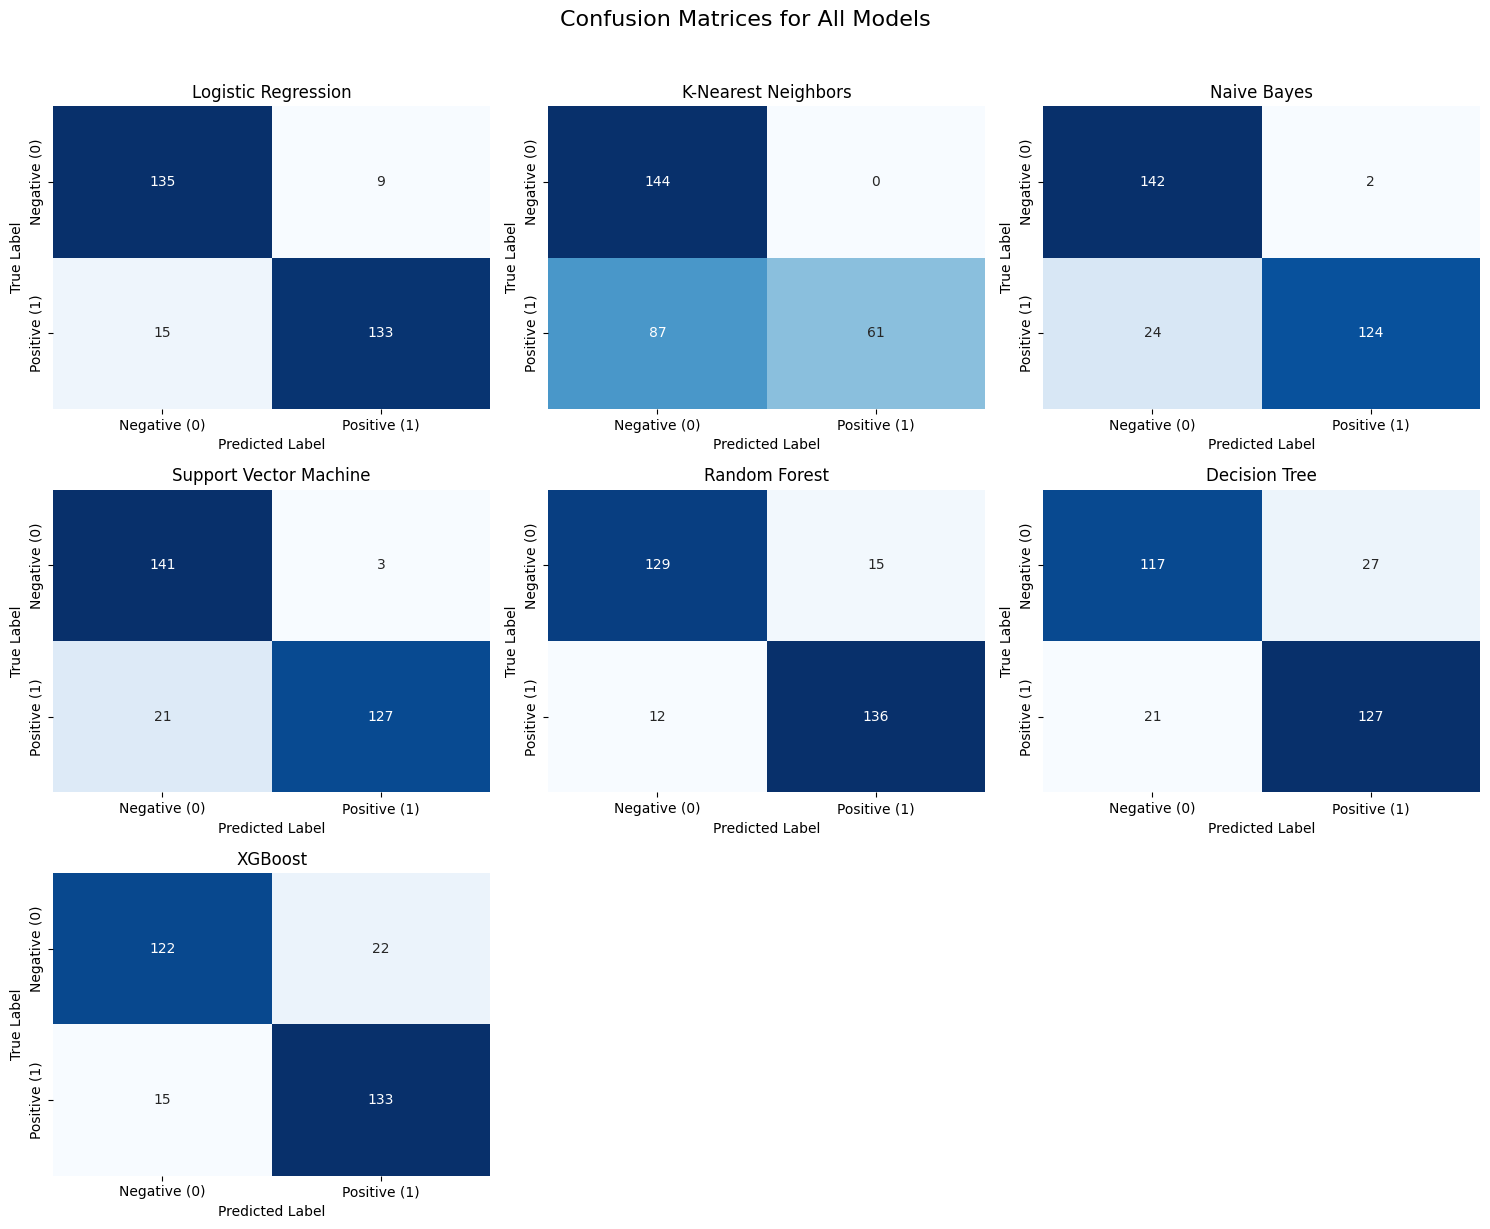

In [237]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Define model names and their corresponding confusion matrices
models_confusion_matrices = {
    "Logistic Regression": conf_matrix,
    "K-Nearest Neighbors": conf_matrix_knn,
    "Naive Bayes": conf_matrix_nb,
    "Support Vector Machine": conf_matrix_svm,
    "Random Forest": conf_matrix_rf,
    "Decision Tree": conf_matrix_dt,
    "XGBoost": conf_matrix_xgb
}

# Determine the number of subplots needed (e.g., 3 rows, 3 columns for 7 models, 2,2)
num_models = len(models_confusion_matrices)
num_cols = 3 # You can adjust this for better layout
num_rows = (num_models + num_cols - 1) // num_cols # Ceiling division

plt.figure(figsize=(num_cols * 5, num_rows * 4))
plt.suptitle('Confusion Matrices for All Models', fontsize=16, y=1.02)

for i, (model_name, cm) in enumerate(models_confusion_matrices.items()):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Negative (0)', 'Positive (1)'],
                yticklabels=['Negative (0)', 'Positive (1)'])
    plt.title(model_name)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

plt.tight_layout()
plt.show()

In [234]:
def program_nlp(text: str, model) -> str:
    preprocessed_text = preprocess_text(text)
    # Wrap preprocessed_text in a list to make it iterable
    features_extracted = tfidf_vectorizer.transform([preprocessed_text])
    output = model.predict(features_extracted)
    # output is an array of label indices, so output[0] is the predicted label index
    return mapping_dict_n2l[output[0]]

text = "I am so happy to expericne this travel. it was so good and awesome"
out = program_nlp(text, logistic_model)
print("Sentiment Detected:".upper(),out.upper())

SENTIMENT DETECTED: POSITIVE


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [235]:
# Simple chatbot using program_nlp to detect emotion from user input
while True:
    user_input = input("Tell me your opinion (or type 'exit' to quit): ")
    if user_input.lower() == 'exit':
        print("Goodbye! and See you again")
        break
    emotion = program_nlp(user_input, random_forest_model)
    print(f"Your emotion is: {emotion}")

Tell me your opinion (or type 'exit' to quit): The place is good and medical staff were professional and the place was clean and everything is good so far.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Your emotion is: positive
Tell me your opinion (or type 'exit' to quit): the experience was terrible for me. I am not going to recommned this expericne again to anyone i konw, the place was dirty and the medcial staff was not professional and they were rude and not polite at all.
Your emotion is: negative
Tell me your opinion (or type 'exit' to quit): The secretary was so rude and was provocative. I wanted to report her and i hope she is not going to work again in the hospital again in the future.
Your emotion is: negative
Tell me your opinion (or type 'exit' to quit): The nurse was helpful and supportive. She was kind and was there with me all the time. She is an amazing person and really likes to help people. I am going to recommend her in any medical healthcare center for sure.
Your emotion is: positive
Tell me your opinion (or type 'exit' to quit): exit
Goodbye! and See you again


In [238]:
# Simple chatbot using program_nlp to detect emotion from user input
while True:
    user_input = input("Tell me your opinion (or type 'exit' to quit): ")
    if user_input.lower() == 'exit':
        print("Goodbye! and See you again")
        break
    emotion = program_nlp(user_input, logistic_model)
    print(f"Your emotion is: {emotion}")

Tell me your opinion (or type 'exit' to quit): The place was organized and medical staff were professional and helpful. I have enjoyed the experience it was really a good one.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Your emotion is: positive
Tell me your opinion (or type 'exit' to quit): The place was so dirty and not clean at all. The bathrooms were disgusting and there were poeple smoking in the hospital and medical staff were not caring for the patients at all. The place was awful and bad.
Your emotion is: negative
Tell me your opinion (or type 'exit' to quit): The doctor was not communicative and not kind. He was not comfortable and not supportive. I wanted to ask him for more questions regarding my health  condition but he refused to listen to me. I want to report him as a not a good and not a professioanl doctor.
Your emotion is: positive
Tell me your opinion (or type 'exit' to quit): exit
Goodbye! and See you again
